1. Imports

In [54]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import re, string, unicodedata # type: ignore
import warnings # type: ignore
warnings.filterwarnings('ignore')

import seaborn as sns # type: ignore
import matplotlib.pyplot as plt # type: ignore
import plotly.express as px # type: ignore

import nltk # type: ignore
from nltk.stem import WordNetLemmatizer # type: ignore
from nltk.tokenize import word_tokenize # type: ignore
from nltk.corpus import wordnet # type: ignore
from nltk.corpus import stopwords # type: ignore

from sklearn.feature_extraction.text import CountVectorizer # type: ignore
from wordcloud import WordCloud, STOPWORDS # type: ignore
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score # type: ignore
from sklearn.model_selection import train_test_split # type: ignore
from string import punctuation # type: ignore

2. Loading the dataset

In [55]:
%%time
df = pd.read_csv('/Users/treva.ogwang/Desktop/Codes/social_media/sentimentdataset.csv')

CPU times: user 6.79 ms, sys: 2.64 ms, total: 9.44 ms
Wall time: 7.28 ms


First 10 rows of the dataset.

In [56]:
df.head(10)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
5,5,5,Feeling grateful for the little things in lif...,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9
6,6,6,Rainy days call for cozy blankets and hot coc...,Positive,2023-01-16 14:45:00,RainyDays,Facebook,#RainyDays #Cozy,10.0,20.0,Canada,2023,1,16,14
7,7,7,The new movie release is a must-watch! ...,Positive,2023-01-16 19:30:00,MovieBuff,Instagram,#MovieNight #MustWatch,15.0,30.0,USA,2023,1,16,19
8,8,8,Political discussions heating up on the timel...,Negative,2023-01-17 08:00:00,DebateTalk,Twitter,#Politics #Debate,30.0,60.0,USA,2023,1,17,8
9,9,9,Missing summer vibes and beach days. ...,Neutral,2023-01-17 12:20:00,BeachLover,Facebook,#Summer #BeachDays,18.0,35.0,Australia,2023,1,17,12


3. Data Overview

In [57]:
#Checking missing value
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [58]:
df['Text'].describe()

count                                                   732
unique                                                  707
top        A compassionate rain, tears of empathy fallin...
freq                                                      3
Name: Text, dtype: object

In [59]:
df['Platform'].describe()

count             732
unique              4
top        Instagram 
freq              258
Name: Platform, dtype: object

4. Data Cleaning

A) Downloading the stop words

In [60]:
#Downloading the stopwords from nltk
nltk.download("stopwords")

#List of stop words 
stop_words = set(stopwords.words('english'))

#Displaying the stop words
print(stop_words)

{'herself', 'did', 'will', "shan't", 'after', 'my', 'ma', 'now', 'each', "needn't", 'most', 'an', 'any', 'hadn', 'himself', 'mightn', 'her', 'haven', 'you', 'been', "doesn't", 'his', 'too', 'does', 'theirs', 'me', "aren't", 'that', 'yourselves', 'by', 'have', 's', 'ourselves', "mightn't", 'having', 'their', 'from', "that'll", 'of', 've', 'doesn', "won't", 'had', 'm', "couldn't", 'because', 'was', 'were', 'do', 'but', "don't", 'wouldn', 'our', 'nor', 'own', 'while', 'under', 'above', 'y', 'about', 'he', 'them', "you'll", 'these', 'be', 'few', 'very', 'what', "you'd", 'until', 'yourself', 'couldn', 'i', 'its', 'the', "it's", 'a', "isn't", 'this', 'can', 'once', "weren't", 'and', "shouldn't", 'both', 'than', 'myself', 'no', 'with', "you're", 'down', 'shan', 'over', 'against', 'to', 'we', 'such', 'isn', 'between', 'am', 'some', "should've", 'aren', 'out', "didn't", "hadn't", "wasn't", 'ours', 'she', 'him', 'hers', 'on', 'd', 'below', 'ain', 'whom', 'll', 't', 'which', 'at', 'just', 'same',

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/treva.ogwang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


B) Creating a function to clean the data set.

In [61]:
#Creating a function to clean the dataset.

def clean_text(text):
    text = text.lower() #Convert text to lower-case
    text = re.sub(r'http\S+|www.\S+', '', text) #Removing URL
    text = re.sub(r'\d+', '', text) #Removing digits
    text = text.translate(str.maketrans('', '', string.punctuation)) #Removing punctuation
    text = text.strip() #Removing white spaces
    text = re.sub(r'@\S+', '', text) # Remove mentions (e.g., @username)
    text = re.sub(r'#\S+', '', text) # Remove hashtags (e.g., #hashtag)
    text = re.sub(r'[^a-z\s]', '', text)     # Remove non-alphabetic characters (punctuation and numbers)
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # Remove non-ASCII characters (including emojis)
    
    text = text.split() #Splitting the text
    text = [word for word in text if word not in stop_words] #Removing stop words
    text = ' '.join(text) #Joining the text
    
    return text

#Applying the function to the dataset and storing it in a new column named 'Cleaned_Text'
df['Cleaned_Text'] = df['Text'].astype(str).apply(clean_text)

df.head(10)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Cleaned_Text
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying beautiful day park
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic terrible morning
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,finished amazing workout
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited upcoming weekend getaway
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying new recipe dinner tonight
5,5,5,Feeling grateful for the little things in lif...,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9,feeling grateful little things life
6,6,6,Rainy days call for cozy blankets and hot coc...,Positive,2023-01-16 14:45:00,RainyDays,Facebook,#RainyDays #Cozy,10.0,20.0,Canada,2023,1,16,14,rainy days call cozy blankets hot cocoa
7,7,7,The new movie release is a must-watch! ...,Positive,2023-01-16 19:30:00,MovieBuff,Instagram,#MovieNight #MustWatch,15.0,30.0,USA,2023,1,16,19,new movie release mustwatch
8,8,8,Political discussions heating up on the timel...,Negative,2023-01-17 08:00:00,DebateTalk,Twitter,#Politics #Debate,30.0,60.0,USA,2023,1,17,8,political discussions heating timeline
9,9,9,Missing summer vibes and beach days. ...,Neutral,2023-01-17 12:20:00,BeachLover,Facebook,#Summer #BeachDays,18.0,35.0,Australia,2023,1,17,12,missing summer vibes beach days


In [62]:
#Converting the string in the 'Platform' column to lower case
df['Platform'] = df['Platform'].str.lower()

# Remove leading and trailing white spaces from the 'Platform' column
df['Platform'] = df['Platform'].str.strip()

In [63]:
# Dropping the columns that are not necessary for the analysis
df_cleaned = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'User', 'Hashtags', 'Timestamp', 'Sentiment'])

df_cleaned.head(10)

,Text,Platform,Retweets,Likes,Country,Year,Month,Day,Hour,Cleaned_Text
0,Enjoying a beautiful day at the park! ...,twitter,15.0,30.0,USA,2023,1,15,12,enjoying beautiful day park
1,Traffic was terrible this morning. ...,twitter,5.0,10.0,Canada,2023,1,15,8,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,instagram,20.0,40.0,USA,2023,1,15,15,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,facebook,8.0,15.0,UK,2023,1,15,18,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,instagram,12.0,25.0,Australia,2023,1,15,19,trying new recipe dinner tonight
5,Feeling grateful for the little things in lif...,twitter,25.0,50.0,India,2023,1,16,9,feeling grateful little things life
6,Rainy days call for cozy blankets and hot coc...,facebook,10.0,20.0,Canada,2023,1,16,14,rainy days call cozy blankets hot cocoa
7,The new movie release is a must-watch! ...,instagram,15.0,30.0,USA,2023,1,16,19,new movie release mustwatch
8,Political discussions heating up on the timel...,twitter,30.0,60.0,USA,2023,1,17,8,political discussions heating timeline
9,Missing summer vibes and beach days. ...,facebook,18.0,35.0,Australia,2023,1,17,12,missing summer vibes beach days


In [64]:
columns_order = ['Text', 'Cleaned_Text', 'Platform', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

# Reordering the DataFrame
df_cleaned = df_cleaned[columns_order]

# Check the new column order
df_cleaned.head()

,Text,Cleaned_Text,Platform,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,twitter,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,traffic terrible morning,twitter,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,finished amazing workout,instagram,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,facebook,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,instagram,12.0,25.0,Australia,2023,1,15,19


Exploratory Data Analysis

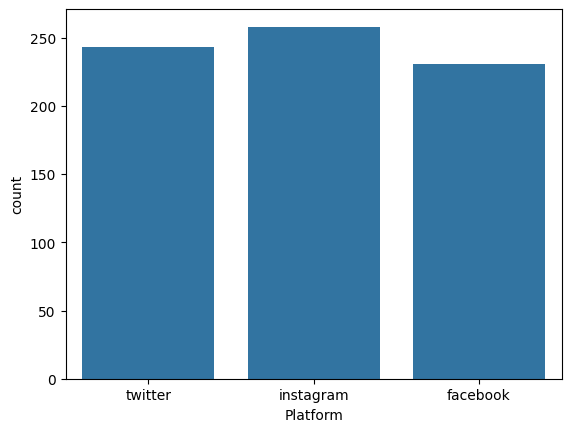

Platform
instagram    258
twitter      243
facebook     231
Name: count, dtype: int64


In [65]:
#Checking for Imbalance by checking the amount of text in each platform.
sns.countplot(x=df['Platform'])
plt.show()
print(df['Platform'].value_counts())